# NLP Lab — Complete Tasks 1 to 5

**Datasets:** `US_Declaration.pdf` | `moviereviews.tsv`

| Task | Topic |
|------|-------|
| Task 1 | File Loading & Dataset Setup |
| Task 2 | NLP Pipeline — Tokenization, Stemming, Lemmatization, Stopwords |
| Task 3 | Vocabulary & Matching — NER, Noun Chunks, Pattern Matching |
| Task 4 | Text Classification — Logistic Regression |
| Task 5 | Sentiment Analysis |

## Step 0: Install & Import All Libraries

In [ ]:
!pip install PyMuPDF nltk spacy textblob scikit-learn matplotlib wordcloud --quiet
!python -m spacy download en_core_web_sm -q

import fitz
import nltk
import spacy
import random
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from wordcloud import WordCloud
from IPython.display import display

for pkg in ['punkt','punkt_tab','stopwords','wordnet','averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords

nlp = spacy.load('en_core_web_sm')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score)
from textblob import TextBlob

print('All libraries loaded successfully!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 64.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
All libraries loaded successfully!


---
## TASK 1: Load Dataset Files

> Upload both files via the Colab file panel (left sidebar → upload icon)

In [ ]:
# ── Load US Declaration PDF ──────────────────────────────────────────────────
def load_pdf(path):
    doc = fitz.open(path)
    text = ''.join(page.get_text() for page in doc)
    doc.close()
    return text

pdf_text = load_pdf('US_Declaration.pdf')
pdf_sentences = [s.strip() for s in sent_tokenize(pdf_text) if len(s.split()) > 6]

print(f'PDF loaded | Characters: {len(pdf_text)} | Sentences: {len(pdf_sentences)}')
print('\nFirst 400 chars:\n', pdf_text[:400])

PDF loaded | Characters: 9528 | Sentences: 36

First 400 chars:
 Declaration of Independence
IN CONGRESS, July 4, 1776. 
The unanimous Declaration of the thirteen united States of America, 
When in the Course of human events, it becomes necessary for one people to dissolve the
political bands which have connected them with another, and to assume among the powers of the
earth, the separate and equal station to which the Laws of Nature and of Nature's God entitle


In [ ]:
# ── Load Movie Reviews TSV ───────────────────────────────────────────────────
df = pd.read_csv('moviereviews.tsv', sep='\t')
print(f'Movie Reviews loaded | Shape: {df.shape}')
print(f'Labels: {df["label"].value_counts().to_dict()}')
display(df.head(3))

Movie Reviews loaded | Shape: (2000, 2)
Labels: {'neg': 1000, 'pos': 1000}


,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...


---
## TASK 2: NLP Pipeline
**Tokenization → Stemming → Lemmatization → Stopwords**

In [ ]:
# ── 2A. Pick Random Sentence from PDF ───────────────────────────────────────
random.seed(42)
sentence = random.choice(pdf_sentences)
print('RANDOMLY SELECTED SENTENCE:')
print('='*70)
print(sentence)
print('='*70)

RANDOMLY SELECTED SENTENCE:
He has refused his Assent to Laws, the most wholesome and necessary for the
public good.


Word Tokens (18):
['He', 'has', 'refused', 'his', 'Assent', 'to', 'Laws', ',', 'the', 'most', 'wholesome', 'and', 'necessary', 'for', 'the', 'public', 'good', '.']

Sentence Tokens (1):
['He has refused his Assent to Laws, the most wholesome and necessary for the\npublic good.']


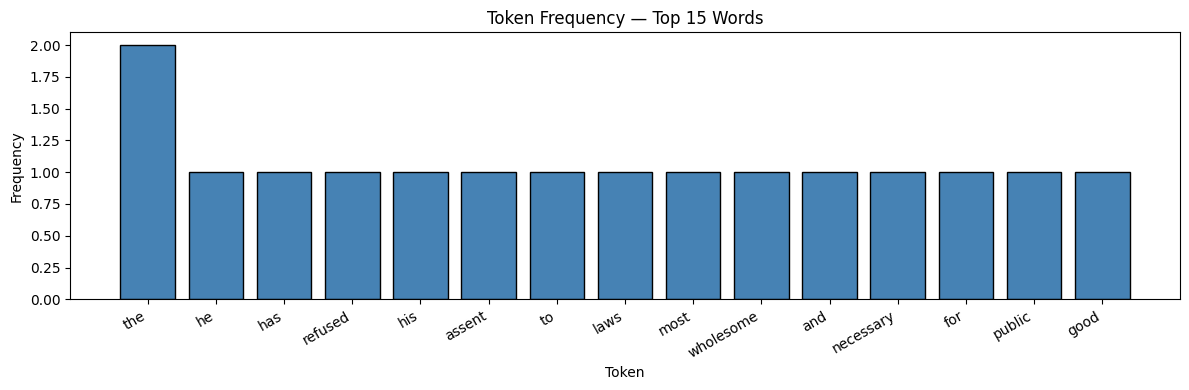

In [ ]:
# ── 2B. Tokenization ─────────────────────────────────────────────────────────
word_tokens = word_tokenize(sentence)
sent_tokens = sent_tokenize(sentence)

print(f'Word Tokens ({len(word_tokens)}):')
print(word_tokens)
print(f'\nSentence Tokens ({len(sent_tokens)}):')
print(sent_tokens)

# Bar chart of token frequencies
alpha_tokens = [t.lower() for t in word_tokens if t.isalpha()]
freq = Counter(alpha_tokens)
if freq:
    top = freq.most_common(15)
    words_t, counts_t = zip(*top)
    plt.figure(figsize=(12,4))
    plt.bar(words_t, counts_t, color='steelblue', edgecolor='black')
    plt.title('Token Frequency — Top 15 Words')
    plt.xlabel('Token'); plt.ylabel('Frequency')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()

In [ ]:
# ── 2C. Stemming ─────────────────────────────────────────────────────────────
stemmer = PorterStemmer()
stemmed = [(t, stemmer.stem(t)) for t in word_tokens if t.isalpha()]

print('STEMMING (Porter Stemmer)')
print(f'{"Original":<25} {"Stemmed"}')
print('-'*45)
for orig, stem in stemmed:
    mark = ' <- changed' if orig.lower() != stem else ''
    print(f'{orig:<25} {stem}{mark}')

STEMMING (Porter Stemmer)
Original                  Stemmed
---------------------------------------------
He                        he
has                       ha <- changed
refused                   refus <- changed
his                       hi <- changed
Assent                    assent
to                        to
Laws                      law <- changed
the                       the
most                      most
wholesome                 wholesom <- changed
and                       and
necessary                 necessari <- changed
for                       for
the                       the
public                    public
good                      good


In [ ]:
# ── 2D. Lemmatization ────────────────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
lemmatized = []
for t in word_tokens:
    if t.isalpha():
        l_v = lemmatizer.lemmatize(t.lower(), pos='v')
        l_n = lemmatizer.lemmatize(t.lower(), pos='n')
        lemma = l_v if l_v != t.lower() else l_n
        lemmatized.append((t, lemma))

print('LEMMATIZATION (WordNet)')
print(f'{"Original":<25} {"Lemma":<20} {"Changed?"}')
print('-'*55)
for orig, lemma in lemmatized:
    changed = 'YES' if orig.lower() != lemma else ''
    print(f'{orig:<25} {lemma:<20} {changed}')

# Stemming vs Lemmatization comparison table
print('\nCOMPARISON: Stemming vs Lemmatization')
print(f'{"Original":<20} {"Stemmed":<20} {"Lemmatized"}')
print('-'*60)
stem_d  = {o: s for o, s in stemmed}
lemma_d = {o: l for o, l in lemmatized}
for t in word_tokens:
    if t.isalpha():
        print(f'{t:<20} {stem_d.get(t,"-"):<20} {lemma_d.get(t,"-")}')

LEMMATIZATION (WordNet)
Original                  Lemma                Changed?
-------------------------------------------------------
He                        he                   
has                       have                 YES
refused                   refuse               YES
his                       his                  
Assent                    assent               
to                        to                   
Laws                      law                  YES
the                       the                  
most                      most                 
wholesome                 wholesome            
and                       and                  
necessary                 necessary            
for                       for                  
the                       the                  
public                    public               
good                      good                 

COMPARISON: Stemming vs Lemmatization
Original             Stemmed              Lemmat

STOP WORD IDENTIFICATION
Total tokens   : 18
Stop words     : 9 -> ['He', 'has', 'his', 'to', 'the', 'most', 'and', 'for', 'the']
Content words  : 7 -> ['refused', 'Assent', 'Laws', 'wholesome', 'necessary', 'public', 'good']


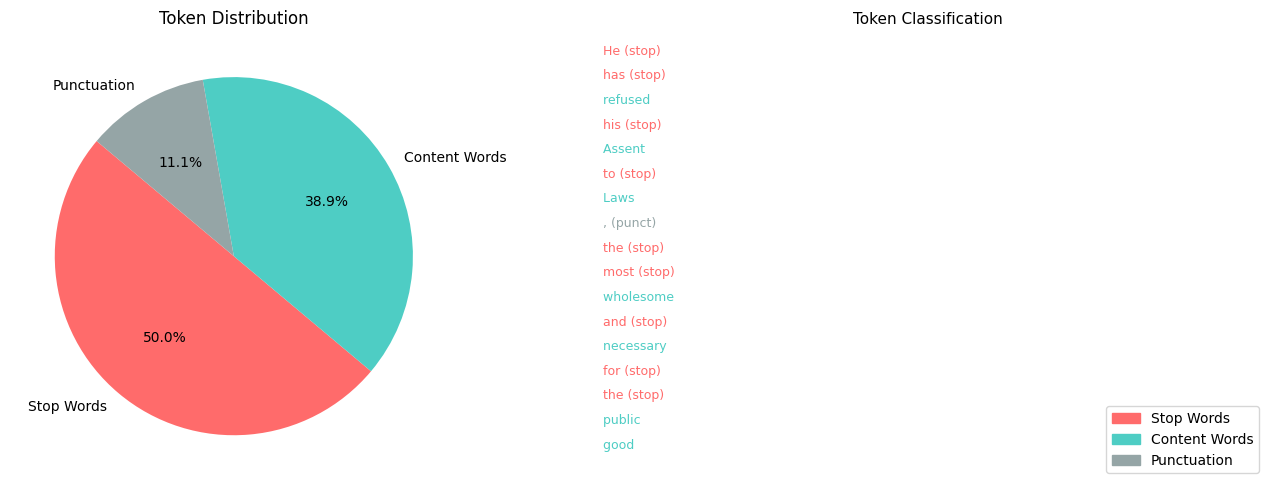

Task 2 Complete!


In [ ]:
# ── 2E. Stop Word Identification ─────────────────────────────────────────────
stop_words = set(stopwords.words('english'))
stop_toks    = [t for t in word_tokens if t.lower() in stop_words]
content_toks = [t for t in word_tokens if t.lower() not in stop_words and t.isalpha()]
punct_toks   = [t for t in word_tokens if not t.isalpha()]

print('STOP WORD IDENTIFICATION')
print(f'Total tokens   : {len(word_tokens)}')
print(f'Stop words     : {len(stop_toks)} -> {stop_toks}')
print(f'Content words  : {len(content_toks)} -> {content_toks}')

# Visualization
colors_map = {'#FF6B6B': 'Stop Words', '#4ECDC4': 'Content Words', '#95A5A6': 'Punctuation'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie
sizes  = [len(stop_toks), len(content_toks), len(punct_toks)]
labels = ['Stop Words', 'Content Words', 'Punctuation']
cols   = ['#FF6B6B', '#4ECDC4', '#95A5A6']
axes[0].pie(sizes, labels=labels, colors=cols, autopct='%1.1f%%', startangle=140)
axes[0].set_title('Token Distribution')

# Color-coded list
axes[1].axis('off')
axes[1].set_title('Token Classification', fontsize=11)
y = 0.95
for tok in word_tokens:
    if tok.lower() in stop_words:
        c, lbl = '#FF6B6B', '(stop)'
    elif not tok.isalpha():
        c, lbl = '#95A5A6', '(punct)'
    else:
        c, lbl = '#4ECDC4', ''
    axes[1].text(0.02, y, f'{tok} {lbl}', color=c, fontsize=9, transform=axes[1].transAxes)
    y -= 0.055
    if y < 0.02: break

handles = [mpatches.Patch(color=c, label=l) for c, l in colors_map.items()]
axes[1].legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.savefig('task2_nlp_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Task 2 Complete!')

---
## TASK 3: Vocabulary & Matching
**NER → Noun Chunks → Dependency Diagram → Pattern Matching**

In [ ]:
# ── 3A. Pick a Sentence Rich in Entities ────────────────────────────────────
random.seed(7)
entity_sent = None
for _ in range(200):
    cand = random.choice(pdf_sentences)
    doc_test = nlp(cand)
    if len(doc_test.ents) >= 2 and len(list(doc_test.noun_chunks)) >= 2:
        entity_sent = cand
        break

if entity_sent is None:
    entity_sent = ("The history of the present King of Great Britain is a history "
                   "of repeated injuries and usurpations, all having in direct object "
                   "the establishment of an absolute Tyranny over these States.")

doc = nlp(entity_sent)
print('SENTENCE FOR TASK 3:')
print('='*70)
print(entity_sent)
print('='*70)

SENTENCE FOR TASK 3:
He has refused to pass other Laws for the accommodation of large districts of
people, unless those people would relinquish the right of Representation in the
Legislature, a right inestimable to them and formidable to tyrants only.


NAMED ENTITY RECOGNITION
Entity Text                    Label        Explanation
------------------------------------------------------------
Representation                 FAC          Buildings, airports, highways, bridges, etc.
Legislature                    ORG          Companies, agencies, institutions, etc.


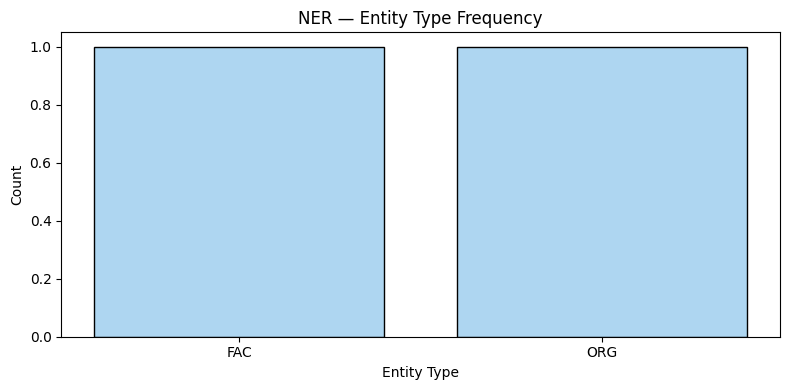

In [ ]:
# ── 3B. Named Entity Recognition ────────────────────────────────────────────
print('NAMED ENTITY RECOGNITION')
print(f'{"Entity Text":<30} {"Label":<12} {"Explanation"}')
print('-'*60)
for ent in doc.ents:
    print(f'{ent.text:<30} {ent.label_:<12} {spacy.explain(ent.label_)}')

# NER bar chart
ent_labels = [ent.label_ for ent in doc.ents]
if ent_labels:
    label_count = Counter(ent_labels)
    plt.figure(figsize=(8,4))
    plt.bar(label_count.keys(), label_count.values(),
            color='#AED6F1', edgecolor='black')
    plt.title('NER — Entity Type Frequency')
    plt.xlabel('Entity Type'); plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('task3_ner.png', dpi=150, bbox_inches='tight')
    plt.show()

NOUN CHUNKS
Chunk                               Root            Root Dep
----------------------------------------------------------
He                                  He              nsubj
other Laws                          Laws            dobj
the accommodation                   accommodation   pobj
large districts                     districts       pobj
people                              people          pobj
those people                        people          nsubj
the right                           right           dobj
Representation                      Representation  pobj
the
Legislature                     Legislature     pobj
them                                them            pobj
tyrants                             tyrants         pobj


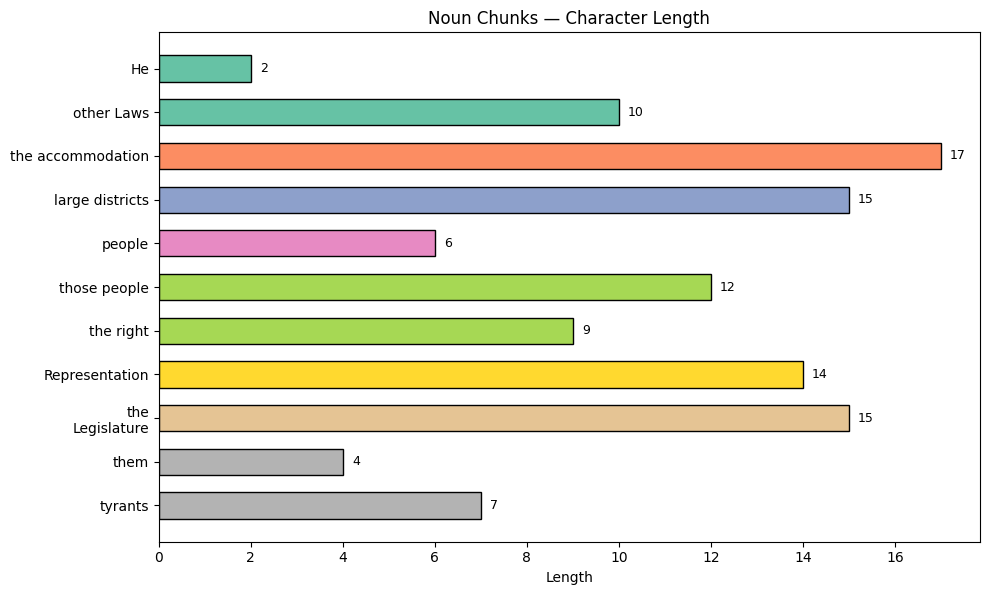

In [ ]:
# ── 3C. Noun Chunks ──────────────────────────────────────────────────────────
noun_chunks = list(doc.noun_chunks)
print('NOUN CHUNKS')
print(f'{"Chunk":<35} {"Root":<15} {"Root Dep"}')
print('-'*58)
for chunk in noun_chunks:
    print(f'{chunk.text:<35} {chunk.root.text:<15} {chunk.root.dep_}')

if noun_chunks:
    texts  = [c.text for c in noun_chunks]
    lens   = [len(c.text) for c in noun_chunks]
    colors = plt.cm.Set2(np.linspace(0,1,len(texts)))
    plt.figure(figsize=(10, max(3, len(texts)*0.55)))
    bars = plt.barh(texts, lens, color=colors, edgecolor='black', height=0.6)
    for bar, val in zip(bars, lens):
        plt.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=9)
    plt.gca().invert_yaxis()
    plt.title('Noun Chunks — Character Length')
    plt.xlabel('Length')
    plt.tight_layout()
    plt.savefig('task3_noun_chunks.png', dpi=150, bbox_inches='tight')
    plt.show()

DEPENDENCY PARSE (first 15 tokens)
Token           POS      Dep          Head
--------------------------------------------------
He              PRON     nsubj        refused
has             AUX      aux          refused
refused         VERB     ROOT         refused
to              PART     aux          pass
pass            VERB     xcomp        refused
other           ADJ      amod         Laws
Laws            NOUN     dobj         pass
for             ADP      prep         pass
the             DET      det          accommodation
accommodation   NOUN     pobj         for
of              ADP      prep         accommodation
large           ADJ      amod         districts
districts       NOUN     pobj         of
of              ADP      prep         districts

               SPACE    dep          of


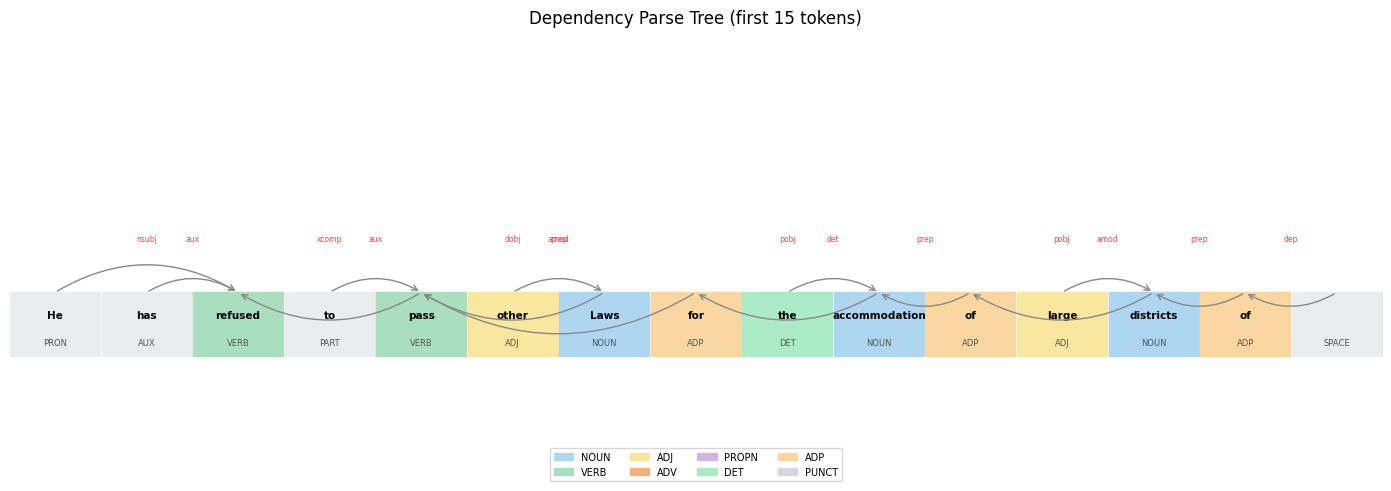

In [ ]:
# ── 3D. Dependency Parse Diagram ─────────────────────────────────────────────
short_doc = nlp(' '.join([t.text for t in doc[:15]]))

print('DEPENDENCY PARSE (first 15 tokens)')
print(f'{"Token":<15} {"POS":<8} {"Dep":<12} {"Head"}')
print('-'*50)
for token in short_doc:
    print(f'{token.text:<15} {token.pos_:<8} {token.dep_:<12} {token.head.text}')

pos_colors = {'NOUN':'#AED6F1','VERB':'#A9DFBF','ADJ':'#F9E79F',
              'ADV':'#F0B27A','PROPN':'#D2B4DE','DET':'#ABEBC6',
              'ADP':'#FAD7A0','PUNCT':'#D5D8DC'}

tokens = list(short_doc)
n = len(tokens)
xs = np.linspace(0.03, 0.97, n)

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')
ax.set_title('Dependency Parse Tree (first 15 tokens)', fontsize=12)

y_tok = 0.25
for i, token in enumerate(tokens):
    col = pos_colors.get(token.pos_, '#EAECEE')
    rect = plt.Rectangle((xs[i]-0.033, y_tok-0.07), 0.066, 0.16,
                          color=col, transform=ax.transAxes, clip_on=False, zorder=2)
    ax.add_patch(rect)
    ax.text(xs[i], y_tok+0.025, token.text, fontsize=7.5, ha='center',
            transform=ax.transAxes, fontweight='bold', zorder=3)
    ax.text(xs[i], y_tok-0.045, token.pos_, fontsize=6, ha='center',
            transform=ax.transAxes, color='#555', zorder=3)

    head_i = token.head.i - short_doc[0].i
    if 0 <= head_i < n and head_i != i:
        ax.annotate('', xy=(xs[head_i], y_tok+0.09), xytext=(xs[i], y_tok+0.09),
                    arrowprops=dict(arrowstyle='->', color='#888',
                                   connectionstyle='arc3,rad=-0.3'),
                    xycoords='axes fraction', textcoords='axes fraction')
        mid_x = (xs[i] + xs[head_i]) / 2
        ax.text(mid_x, y_tok+0.22, token.dep_, fontsize=5.5,
                ha='center', color='#E74C3C', transform=ax.transAxes)

legend_p = [mpatches.Patch(color=c, label=p) for p, c in pos_colors.items()]
ax.legend(handles=legend_p, loc='lower center',
          bbox_to_anchor=(0.5,-0.15), ncol=4, fontsize=7)
plt.tight_layout()
plt.savefig('task3_dependency.png', dpi=150, bbox_inches='tight')
plt.show()

PATTERN MATCHING RESULTS
Pattern              Matched Text
--------------------------------------------------
ADJ_NOUN             other Laws
ADJ_NOUN             large districts


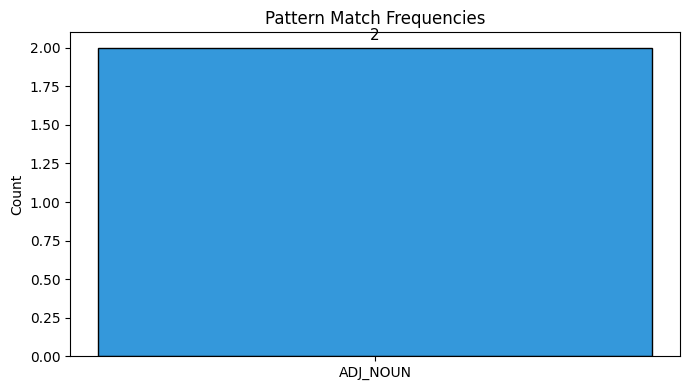

Task 3 Complete!


In [ ]:
# ── 3E. Pattern Matching (spaCy Matcher) ─────────────────────────────────────
from spacy.matcher import Matcher
matcher = Matcher(nlp.vocab)
matcher.add('ADJ_NOUN',   [[{'POS':'ADJ'},  {'POS':'NOUN'}]])
matcher.add('PROPN_NOUN', [[{'POS':'PROPN'},{'POS':'NOUN'}]])
matcher.add('VERB_NOUN',  [[{'POS':'VERB'}, {'POS':'NOUN'}]])

matches = matcher(doc)
print('PATTERN MATCHING RESULTS')
print(f'{"Pattern":<20} {"Matched Text"}')
print('-'*50)
for mid, start, end in matches:
    lbl = nlp.vocab.strings[mid]
    print(f'{lbl:<20} {doc[start:end].text}')

if matches:
    m_labels = [nlp.vocab.strings[mid] for mid, s, e in matches]
    m_count  = Counter(m_labels)
    plt.figure(figsize=(7,4))
    plt.bar(m_count.keys(), m_count.values(),
            color=['#3498DB','#E74C3C','#2ECC71'], edgecolor='black')
    plt.title('Pattern Match Frequencies')
    plt.ylabel('Count')
    for i, (k, v) in enumerate(m_count.items()):
        plt.text(i, v+0.05, str(v), ha='center', fontsize=11)
    plt.tight_layout()
    plt.savefig('task3_patterns.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Task 3 Complete!')

---
## TASK 4: Text Classification — Logistic Regression
**Dataset:** `moviereviews.tsv` (2000 reviews, balanced pos/neg)

In [ ]:
# ── 4A. Preprocess ───────────────────────────────────────────────────────────
df_clean = df.dropna(subset=['review','label']).copy()

def clean_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

df_clean['clean_review'] = df_clean['review'].apply(clean_text)
df_clean['label_enc']    = (df_clean['label'] == 'pos').astype(int)

X = df_clean['clean_review']
y = df_clean['label_enc']

print(f'Dataset: {len(df_clean)} reviews | {df_clean["label"].value_counts().to_dict()}')

Dataset: 1965 reviews | {'neg': 983, 'pos': 982}


In [ ]:
# ── 4B. TF-IDF + Train/Test Split ───────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

print(f'TF-IDF shape: {X_tfidf.shape}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

TF-IDF shape: (1965, 5000)
Train: 1572 | Test: 393


In [ ]:
# ── 4C. Train Logistic Regression ────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Logistic Regression Accuracy: {accuracy*100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

Logistic Regression Accuracy: 78.88%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.78      0.79       197
    Positive       0.78      0.80      0.79       196

    accuracy                           0.79       393
   macro avg       0.79      0.79      0.79       393
weighted avg       0.79      0.79      0.79       393



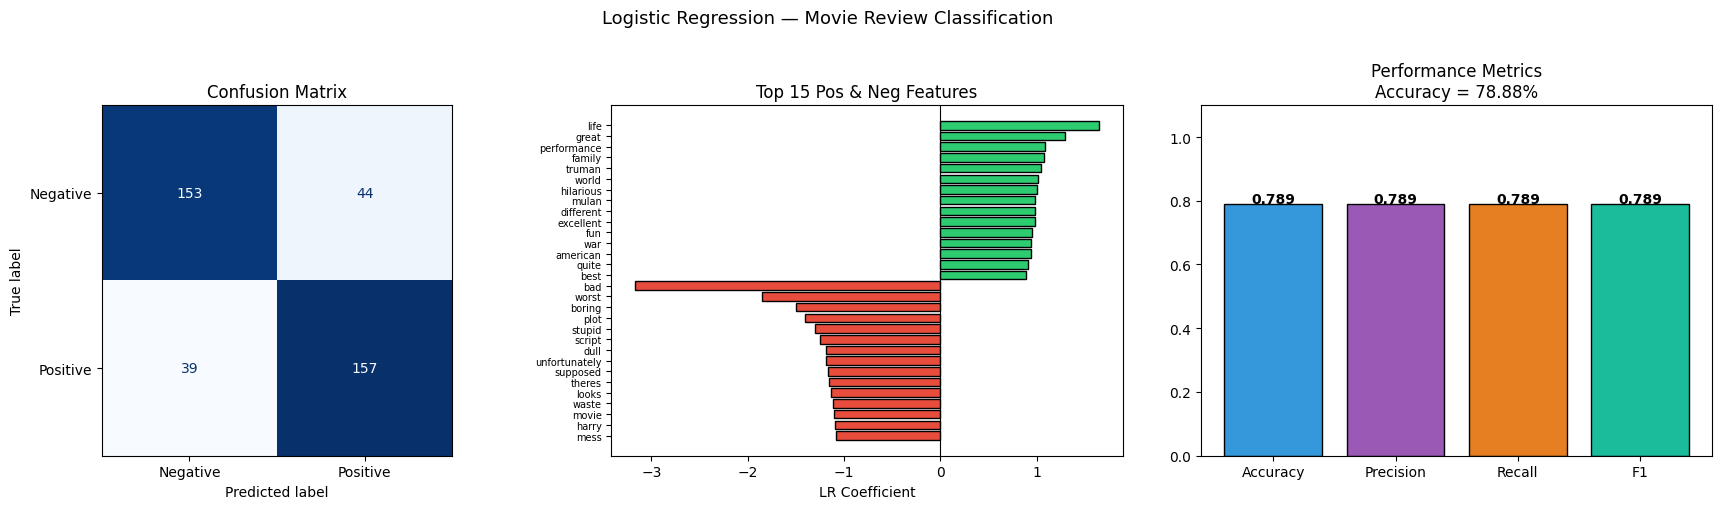

Task 4 Complete! Accuracy = 78.88%


In [ ]:
# ── 4D. Visualize Results ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Top Features
feature_names = np.array(tfidf.get_feature_names_out())
coef = lr_model.coef_[0]
top_pos = np.argsort(coef)[-15:][::-1]
top_neg = np.argsort(coef)[:15]
top_w = np.concatenate([feature_names[top_pos], feature_names[top_neg]])
top_c = np.concatenate([coef[top_pos], coef[top_neg]])
bar_colors = ['#2ECC71' if c > 0 else '#E74C3C' for c in top_c]
axes[1].barh(range(len(top_w)), top_c, color=bar_colors, edgecolor='black')
axes[1].set_yticks(range(len(top_w)))
axes[1].set_yticklabels(top_w, fontsize=7)
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 Pos & Neg Features')
axes[1].set_xlabel('LR Coefficient')

# Metrics Bar
metrics_v = [accuracy,
             precision_score(y_test, y_pred, average='macro'),
             recall_score(y_test, y_pred, average='macro'),
             f1_score(y_test, y_pred, average='macro')]
metrics_n = ['Accuracy','Precision','Recall','F1']
bars = axes[2].bar(metrics_n, metrics_v,
                   color=['#3498DB','#9B59B6','#E67E22','#1ABC9C'], edgecolor='black')
for bar, val in zip(bars, metrics_v):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[2].set_ylim(0, 1.1)
axes[2].set_title(f'Performance Metrics\nAccuracy = {accuracy*100:.2f}%')

plt.suptitle('Logistic Regression — Movie Review Classification', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('task4_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Task 4 Complete! Accuracy = {accuracy*100:.2f}%')

In [ ]:
# ── 4E. Predict Custom Review ────────────────────────────────────────────────
def predict_review(text):
    vec = tfidf.transform([clean_text(text)])
    pred = lr_model.predict(vec)[0]
    prob = lr_model.predict_proba(vec)[0]
    label = 'POSITIVE' if pred == 1 else 'NEGATIVE'
    print(f'Review  : "{text[:70]}"')
    print(f'Result  : {label}  |  Neg: {prob[0]:.2%}  Pos: {prob[1]:.2%}\n')

predict_review("This movie was absolutely fantastic! Great acting and storyline.")
predict_review("Terrible film. Waste of time. The plot made no sense at all.")
predict_review("Visuals were stunning but the story was slow and confusing.")

Review  : "This movie was absolutely fantastic! Great acting and storyline."
Result  : POSITIVE  |  Neg: 39.11%  Pos: 60.89%

Review  : "Terrible film. Waste of time. The plot made no sense at all."
Result  : NEGATIVE  |  Neg: 80.17%  Pos: 19.83%

Review  : "Visuals were stunning but the story was slow and confusing."
Result  : POSITIVE  |  Neg: 41.88%  Pos: 58.12%



---
## TASK 5: Sentiment Analysis
**Datasets:** US Declaration PDF + Movie Reviews TSV

In [ ]:
# ── 5A. Sentiment Function ───────────────────────────────────────────────────
def get_sentiment(text):
    blob = TextBlob(str(text))
    pol  = blob.sentiment.polarity
    sub  = blob.sentiment.subjectivity
    label = 'Positive' if pol > 0.1 else ('Negative' if pol < -0.1 else 'Neutral')
    return pol, sub, label

# Analyze US Declaration sentences
pdf_results = []
for sent in pdf_sentences:
    pol, sub, lbl = get_sentiment(sent)
    pdf_results.append({'sentence': sent[:80]+'...', 'polarity': pol,
                        'subjectivity': sub, 'label': lbl})
df_pdf_sent = pd.DataFrame(pdf_results)

print('US DECLARATION — Sentiment Summary')
print(df_pdf_sent['label'].value_counts().to_string())
print(f"\nAvg Polarity: {df_pdf_sent['polarity'].mean():.4f}")
print(f"Avg Subjectivity: {df_pdf_sent['subjectivity'].mean():.4f}")

US DECLARATION — Sentiment Summary
label
Neutral     18
Positive    15
Negative     3

Avg Polarity: 0.0845
Avg Subjectivity: 0.3722


In [ ]:
# ── 5B. Sentiment on Movie Reviews (sample 200) ──────────────────────────────
df_sample = df_clean.sample(200, random_state=42).copy()
pol_l, sub_l, lbl_l = [], [], []
for text in df_sample['review']:
    pol, sub, lbl = get_sentiment(text)
    pol_l.append(pol); sub_l.append(sub); lbl_l.append(lbl)

df_sample['tb_polarity']     = pol_l
df_sample['tb_subjectivity'] = sub_l
df_sample['tb_label']        = lbl_l
df_sample['tb_binary']       = (df_sample['tb_label'] == 'Positive').astype(int)

tb_accuracy = accuracy_score(df_sample['label_enc'], df_sample['tb_binary'])
print('MOVIE REVIEWS — TextBlob Sentiment Summary (n=200)')
print(df_sample['tb_label'].value_counts().to_string())
print(f"\nTextBlob vs Actual Accuracy: {tb_accuracy*100:.2f}%")

MOVIE REVIEWS — TextBlob Sentiment Summary (n=200)
tb_label
Neutral     122
Positive     76
Negative      2

TextBlob vs Actual Accuracy: 71.00%


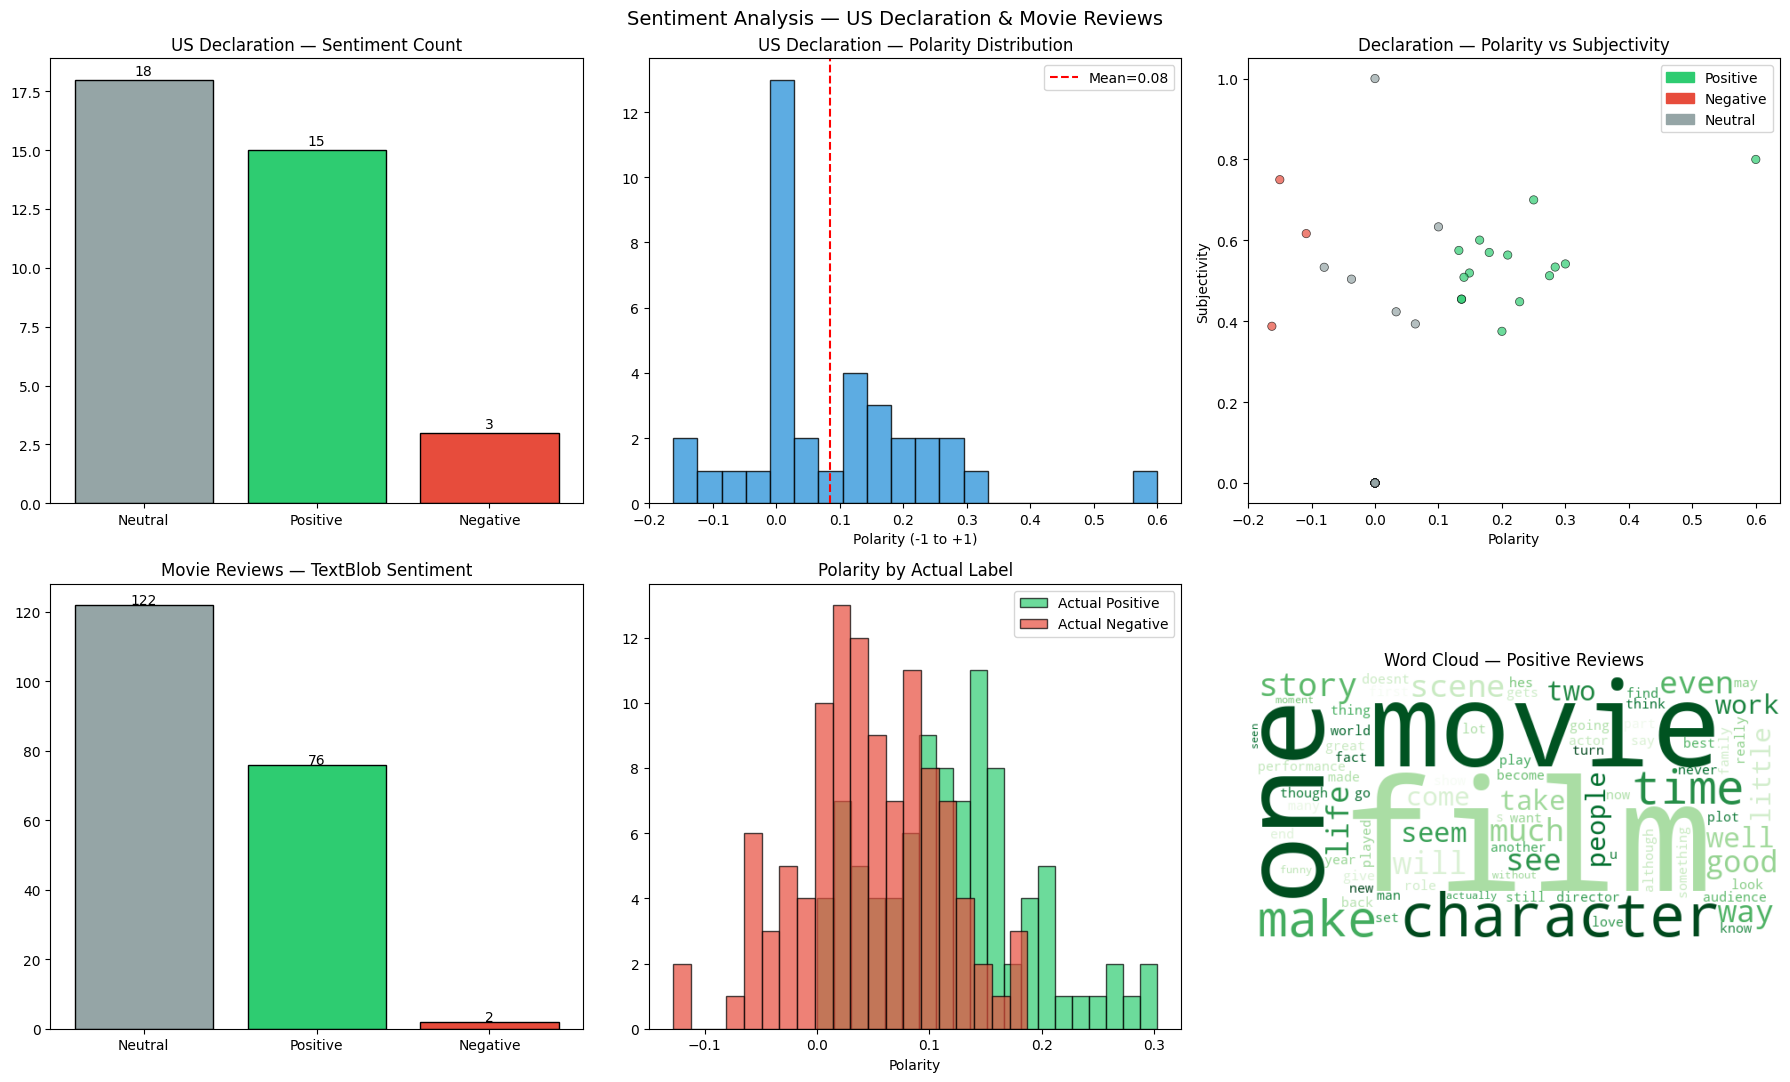

In [ ]:
# ── 5C. Sentiment Visualizations ─────────────────────────────────────────────
sent_colors = {'Positive':'#2ECC71','Negative':'#E74C3C','Neutral':'#95A5A6'}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Sentiment Analysis — US Declaration & Movie Reviews', fontsize=14)

# [0,0] PDF sentiment count
pdf_cnt = df_pdf_sent['label'].value_counts()
axes[0,0].bar(pdf_cnt.index, pdf_cnt.values,
              color=[sent_colors[l] for l in pdf_cnt.index], edgecolor='black')
for i,(idx,v) in enumerate(pdf_cnt.items()): axes[0,0].text(i,v+0.2,str(v),ha='center')
axes[0,0].set_title('US Declaration — Sentiment Count')

# [0,1] PDF polarity histogram
axes[0,1].hist(df_pdf_sent['polarity'], bins=20, color='#3498DB', edgecolor='black', alpha=0.8)
axes[0,1].axvline(df_pdf_sent['polarity'].mean(), color='red', linestyle='--',
                   label=f'Mean={df_pdf_sent["polarity"].mean():.2f}')
axes[0,1].set_title('US Declaration — Polarity Distribution')
axes[0,1].set_xlabel('Polarity (-1 to +1)'); axes[0,1].legend()

# [0,2] PDF scatter: polarity vs subjectivity
lc = df_pdf_sent['label'].map(sent_colors)
axes[0,2].scatter(df_pdf_sent['polarity'], df_pdf_sent['subjectivity'],
                   c=lc, alpha=0.7, edgecolors='k', linewidth=0.5)
axes[0,2].set_xlabel('Polarity'); axes[0,2].set_ylabel('Subjectivity')
axes[0,2].set_title('Declaration — Polarity vs Subjectivity')
axes[0,2].legend(handles=[mpatches.Patch(color=c, label=l) for l,c in sent_colors.items()])

# [1,0] Movie Reviews sentiment count
mv_cnt = df_sample['tb_label'].value_counts()
axes[1,0].bar(mv_cnt.index, mv_cnt.values,
              color=[sent_colors[l] for l in mv_cnt.index], edgecolor='black')
for i,(idx,v) in enumerate(mv_cnt.items()): axes[1,0].text(i,v+0.3,str(v),ha='center')
axes[1,0].set_title('Movie Reviews — TextBlob Sentiment')

# [1,1] Movie polarity by actual label
pos_pol = df_sample[df_sample['label']=='pos']['tb_polarity']
neg_pol = df_sample[df_sample['label']=='neg']['tb_polarity']
axes[1,1].hist(pos_pol, bins=20, alpha=0.7, color='#2ECC71',
               label='Actual Positive', edgecolor='black')
axes[1,1].hist(neg_pol, bins=20, alpha=0.7, color='#E74C3C',
               label='Actual Negative', edgecolor='black')
axes[1,1].set_title('Polarity by Actual Label')
axes[1,1].set_xlabel('Polarity'); axes[1,1].legend()

# [1,2] Word Cloud — Positive Reviews
pos_text = ' '.join(df_clean[df_clean['label']=='pos']['clean_review'].tolist())
wc = WordCloud(width=600, height=300, background_color='white',
               colormap='Greens', max_words=80).generate(pos_text)
axes[1,2].imshow(wc, interpolation='bilinear'); axes[1,2].axis('off')
axes[1,2].set_title('Word Cloud — Positive Reviews')

plt.tight_layout()
plt.savefig('task5_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

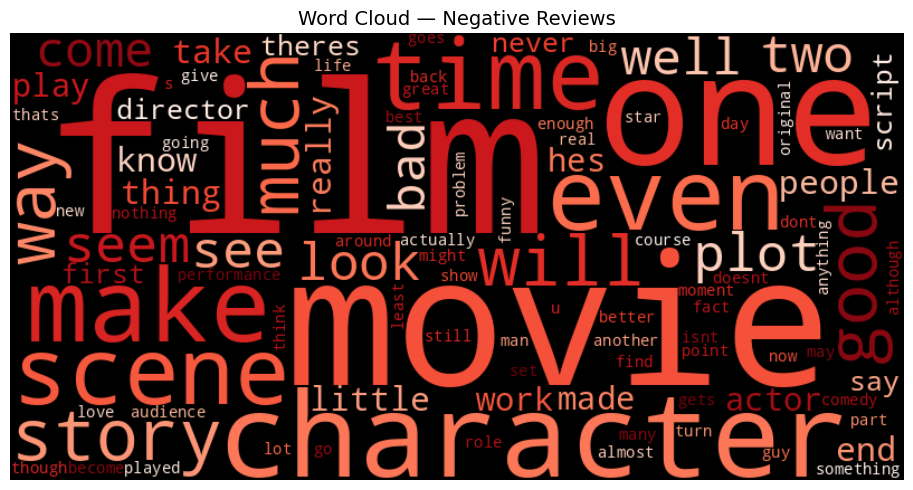

In [ ]:
# ── 5D. Negative Reviews Word Cloud ─────────────────────────────────────────
neg_text = ' '.join(df_clean[df_clean['label']=='neg']['clean_review'].tolist())
wc_neg = WordCloud(width=800, height=400, background_color='black',
                   colormap='Reds', max_words=100).generate(neg_text)
plt.figure(figsize=(12,5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off'); plt.title('Word Cloud — Negative Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('task5_wordcloud_neg.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 5E. Most Positive & Negative PDF Sentences ───────────────────────────────
print('TOP 5 MOST POSITIVE SENTENCES (US Declaration):')
print('='*70)
for _, row in df_pdf_sent.nlargest(5,'polarity').iterrows():
    print(f'  Polarity: {row["polarity"]:+.3f} | {row["sentence"]}')
    print()

print('TOP 5 MOST NEGATIVE SENTENCES (US Declaration):')
print('='*70)
for _, row in df_pdf_sent.nsmallest(5,'polarity').iterrows():
    print(f'  Polarity: {row["polarity"]:+.3f} | {row["sentence"]}')
    print()

print('='*70)
print('ALL 5 TASKS COMPLETED SUCCESSFULLY!')
print('='*70)
print('Task 1 - Files loaded: US_Declaration.pdf + moviereviews.tsv')
print('Task 2 - Tokenization | Stemming | Lemmatization | Stopwords')
print('Task 3 - NER | Noun Chunks | Dependency Diagram | Pattern Matching')
print(f'Task 4 - Logistic Regression Accuracy: {accuracy*100:.2f}%')
print(f'Task 5 - Sentiment Analysis | Word Clouds | Polarity Analysis')

TOP 5 MOST POSITIVE SENTENCES (US Declaration):
  Polarity: +0.600 | To prove this, let Facts be submitted to a
candid world....

  Polarity: +0.300 | He has refused his Assent to Laws, the most wholesome and necessary for the
publ...

  Polarity: +0.284 | Prudence,
indeed, will dictate that Governments long established should not be c...

  Polarity: +0.275 | The history of the present King of Great
Britain is a history of repeated injuri...

  Polarity: +0.250 | A Prince whose character is
thus marked by every act which may define a Tyrant, ...

TOP 5 MOST NEGATIVE SENTENCES (US Declaration):
  Polarity: -0.163 | And for the support of this Declaration, with a firm reliance on the protection ...

  Polarity: -0.150 | We have
appealed to their native justice and magnanimity, and we have conjured t...

  Polarity: -0.108 | He has excited domestic insurrections amongst us, and has endeavoured to bring
o...

  Polarity: -0.080 | He has called together legislative bodies at places unusual

In [1]:
# Install OpenCV if not already installed. 'opencv-python-headless' is suitable for environments without a display.
!pip install opencv-python-headless --quiet

import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np

# Download the pre-trained Haar Cascade classifier for face detection.
# This is a common XML file used by OpenCV for frontal face detection.
haar_cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
haar_cascade_filename = "haarcascade_frontalface_default.xml"

print(f"Downloading {haar_cascade_filename}...")
urllib.request.urlretrieve(haar_cascade_url, haar_cascade_filename)
print("Download complete.")

# Load the cascade classifier
face_cascade = cv2.CascadeClassifier(haar_cascade_filename)

# --- USER INPUT: Provide the path to your image here ---
# Option 1: Upload an image to your Colab environment (e.g., 'my_image.jpg')
# Option 2: Use a URL to download an image first. Example:
# urllib.request.urlretrieve('https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/220px-President_Barack_Obama.jpg', 'obama.jpg')
# image_path = 'obama.jpg'
image_path = 'person_image.jpg' # <--- REPLACE WITH YOUR IMAGE PATH

try:
    # Load the image
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError(f"Error: Image not found at {image_path}. Please ensure the path is correct and the file exists.")

    # Convert to grayscale, as many detection algorithms work better on grayscale images
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect faces in the image
    # detectMultiScale parameters:
    #  - scaleFactor: Parameter specifying how much the image size is reduced at each image scale.
    #  - minNeighbors: Parameter specifying how many neighbors each candidate rectangle should have to retain it.
    #  - minSize: Minimum possible object size. Objects smaller than that are ignored.
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

    print(f"Found {len(faces)} person(s) in the image.")

    # Draw rectangles around the detected faces
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Draw a blue rectangle with thickness 2

    # Display the result using matplotlib
    plt.figure(figsize=(10, 8))
    # Convert BGR (OpenCV default) to RGB for correct matplotlib display
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Identified Persons')
    plt.axis('off') # Hide axes ticks and labels
    plt.show()

except FileNotFoundError as e:
    print(e)
    print("Please make sure you have uploaded the image to your Colab files or provided a valid URL and path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Download complete.
Error: Image not found at person_image.jpg. Please ensure the path is correct and the file exists.
Please make sure you have uploaded the image to your Colab files or provided a valid URL and path.
